In [1]:
import os

# Select the backend before importing folps.py
os.environ["FOLPS_BACKEND"] = "numpy"  #'numpy' or 'jax'

from folps import *
from cosmo_class import *

✅ Using NumPy with CPU.


In [2]:
#linear power spectrum
classy  = run_class(h = 0.6711, ombh2 = 0.022, omch2 = 0.122, omnuh2 = 0.0006442, 
                    As = 2e-9, ns = 0.965, z = 0.3, z_scale=[0.97],
                    N_ur = 2.0328,
                    khmin = 0.0001, khmax = 2.0, nbk = 1000, spectra = 'cb')

kwargs = {'z': 0.3, 'h': 0.6711, 'Omega_m': classy['cosmo'].Omega0_m(), 'f0':classy['cosmo'].scale_independent_growth_factor_f(0.3),
          'fnu':classy['cosmo'].Omega_nu/classy['cosmo'].Omega_m()}

In [3]:
matrix = MatrixCalculator(A_full=True)
mmatrices = matrix.get_mmatrices()

Loading matrices from matrices_nfftlog128_Afull_True_remove-DeltaP_False.npy


In [4]:
%%time
nonlinear = NonLinearPowerSpectrumCalculator(mmatrices=mmatrices,
                                             kernels='fk',
                                             **kwargs)

CPU times: user 307 μs, sys: 45 μs, total: 352 μs
Wall time: 410 μs


In [5]:
%%time
table, table_now = nonlinear.calculate_loop_table(k=classy['k'], pklin=classy['pk'],cosmo=classy['cosmo'], **kwargs)

CPU times: user 129 ms, sys: 19.1 ms, total: 148 ms
Wall time: 68 ms


In [6]:
# Bias parameters
b1 = 1.645
b2 = -0.46
bs2 = -4./7*(b1 - 1)
b3nl = 32./315*(b1 - 1)
# EFT parameters
alpha0 = 3                 #units: [Mpc/h]^2
alpha2 = -28.9             #units: [Mpc/h]^2
alpha4 = 0.0               #units: [Mpc/h]^2
ctilde = 0.0               #units: [Mpc/h]^4
# Stochatic parameters
PshotP = 1. / 0.0002118763
alphashot0 = 0.08
alphashot2 = -8.1          #units: [Mpc/h]^2
X_Fog_pk = 1
pars = [b1, b2, bs2, b3nl, alpha0, alpha2, alpha4, ctilde, alphashot0, alphashot2, PshotP, X_Fog_pk]

qpar, qper = 1., 1.


k = np.logspace(np.log10(0.01), np.log10(0.3), num=100) # array of  output k in [h/Mpc]

In [7]:
%%time
multipoles = RSDMultipolesPowerSpectrumCalculator(model='FOLPSD') 
P0, P2, P4  = multipoles.get_rsd_pkell(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor'
                                       )

[FOLPS] Model Pk: FOLPSD, Damping: lor
CPU times: user 3.14 ms, sys: 1.26 ms, total: 4.4 ms
Wall time: 3.65 ms


In [8]:
#For marginalization:
P0_c, P2_c, P4_c  = get_rsd_pkell_marg_const(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

P0_i, P2_i, P4_i  = get_rsd_pkell_marg_derivatives(kobs=k, qpar=qpar, qper=qper, pars=pars,
                                       table=table, table_now=table_now,
                                       bias_scheme='folps', damping='lor', model = 'FOLPSD'
                                       )

P0_marg = P0_c + (alpha0 * P0_i[0] + alpha2 * P0_i[1] + alpha4 * P0_i[2] + alphashot0 * P0_i[3]+ alphashot2 * P0_i[4])
P2_marg = P2_c + (alpha0 * P2_i[0] + alpha2 * P2_i[1] + alpha4 * P2_i[2] + alphashot0 * P2_i[3]+ alphashot2 * P2_i[4])
P4_marg = P4_c + (alpha0 * P4_i[0] + alpha2 * P4_i[1] + alpha4 * P4_i[2] + alphashot0 * P4_i[3]+ alphashot2 * P4_i[4])

[FOLPS] Model Pk: FOLPSD, Damping: lor


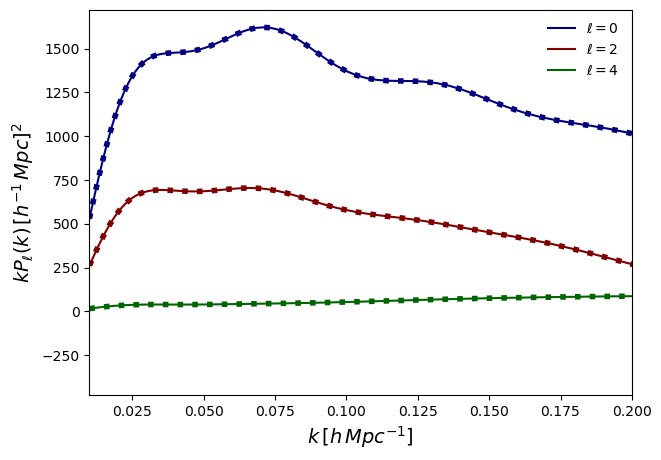

In [9]:
import matplotlib
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k P_{\ell}(k) \, [h^{-1} \,  Mpc]^2$', fontsize =  14)

axs.plot(k, k * P0, color = 'navy', ls='-', label=r'$\ell = 0$')
axs.plot(k, k * P2, color = 'maroon', ls='-', label=r'$\ell = 2$')
axs.plot(k, k * P4, color = 'darkgreen', ls='-', label=r'$\ell = 4$')


axs.plot(k, k * P0_marg, color = 'navy', ls=':', lw=4)
axs.plot(k, k * P2_marg, color = 'maroon', ls=':', lw=4)
axs.plot(k, k * P4_marg, color = 'darkgreen', ls=':', lw=4)

axs.set_xlim([k[0], 0.2])
#axs.set_ylim([-200.0, 1800])

leg1 = axs.legend(loc = 'best');
leg1.get_frame().set_linewidth(0.0);

plt.show()

############################# Bispectrum ###############################3

In [10]:
#pars for Bispectrum
Pshot = 0; # This would be the same as PshopP*alphashot0 if the bispectrum were computed up to 1loop (I think!)
Bshot = 0;
c1=0
c2=0
X_FoG_bk=1

f0 = nonlinear.f0

bpars = [b1, b2, bs2, c1, c2, Bshot, Pshot, X_FoG_bk]

In [11]:
ks = np.logspace(np.log10(0.0001), np.log10(0.4), 30)
k1k2T = np.vstack([ks,ks]).T

In [12]:
bispectrum = BispectrumCalculator(basis='sugiyama', model = 'FOLPSD')

In [13]:
k_pkl_pklnw = np.array([table[0], table[1], table_now[1]])

In [14]:
%%time
B000, B202 = bispectrum.Bisp_Sugiyama(f=f0,  bpars=bpars,
                                      k_pkl_pklnw=k_pkl_pklnw, z_pk=kwargs['z'],
                                      k1k2pairs=k1k2T, qpar=1, qper=1, precision=[10,8,8], damping='lor')

[FOLPS] Model Bk: FOLPSD, Damping: lor
CPU times: user 11.8 ms, sys: 1.52 ms, total: 13.4 ms
Wall time: 12.9 ms


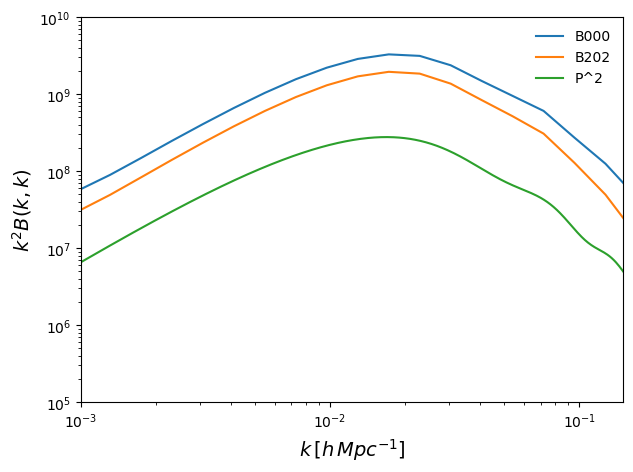

In [15]:
fig, axs = plt.subplots(figsize=(7,5))
axs.set_xlabel(r'$k \, [h\, Mpc^{-1}]$', fontsize =  14)
axs.set_ylabel(r'$k^2 B(k,k) $', fontsize =  14)



axs.loglog(k1k2T.T[0],B000, ls='-', label='B000')
axs.loglog(k1k2T.T[0],B202, ls='-', label='B202')
axs.loglog(nonlinear.inputpkT[0],nonlinear.inputpkT[1]*nonlinear.inputpkT[1], ls='-', label='P^2')



axs.set_xlim([0.001,0.15])
axs.set_ylim([1e5, 1e10])

leg1 = axs.legend(loc = 'best');
leg1.get_frame().set_linewidth(0.0);

plt.show()